# Box quality on normal (lesion-free) images

Sanity check requested by the advisor: when a box is drawn on an image that has
no lesion at all, does the training-free self-assessment score $Q$ (already used
for Claim 9/10) reliably stay low? This notebook does not train anything; it
only runs inference with the already-trained PGA-UNet checkpoint on images with
no ground-truth lesion, so no coverage/Dice can be computed here, only the
distribution of $Q$ itself. Set `DS_NAME` below and rerun for the other dataset.

Expected input: a Google Drive zip whose extracted folder contains only plain
image files (png/jpg), no annotation JSON needed.

In [1]:
# -- Setup ---------------------------------------------------------------
%cd /kaggle/working
import os, gdown, torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

if not os.path.exists('PGA_Unet2D'):
    !git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git
else:
    !cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation && git pull -q

PGA_PATH = '/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'
os.chdir(PGA_PATH)
!pip install -q tqdm opencv-python matplotlib gdown scipy

# ── Choose dataset here, rerun the notebook for the other one ──────────────
DS_NAME = 'BTXRD'   # or 'FracAtlas'

CKPT_ID_BY_DS = {
    'BTXRD':     '19WuyMmN9anS3ErDxfMFj8cOIAJYpxfI0',   # PGA-512 `00` (Dice+BCE, has QualityHead)
    'FracAtlas': '1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU',
}
CKPT_ID = CKPT_ID_BY_DS[DS_NAME]
CKPT_PATH = f'{PGA_PATH}/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
if not os.path.exists(CKPT_PATH):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)

# ── Fill in once each normal-image zip is ready on Drive (separate id per
# dataset - BTXRD is entirely diseased so its zip has to come from an external
# source; FracAtlas's can be repackaged from its native non-fracture images) ──
# Expected zip layout: `Dataset_normal_{dataset}.zip`, images directly inside
# (flat or in subfolders), no annotation file needed.
NORMAL_IMAGES_ID_BY_DS = {
    'BTXRD':     '1SDl-TWl2PgNHxr2aABONtbHe605uGaOm',
    'FracAtlas': '19w_xQSHGOUZUQWwf2iqaw43yMyzCGuMy',
}
NORMAL_IMAGES_DRIVE_ID = NORMAL_IMAGES_ID_BY_DS[DS_NAME]
NORMAL_DIR = f'{PGA_PATH}/normal_images_{DS_NAME.lower()}'
if not os.path.exists(NORMAL_DIR):
    _zip = f'/kaggle/working/normal_images_{DS_NAME.lower()}.zip'
    gdown.download(f'https://drive.google.com/uc?id={NORMAL_IMAGES_DRIVE_ID}', _zip, quiet=False)
    os.makedirs(NORMAL_DIR, exist_ok=True)
    !unzip -oq {_zip} -d {NORMAL_DIR}

RESULT_DIR = f'{PGA_PATH}/results'
os.makedirs(RESULT_DIR, exist_ok=True)
print(f'\nSetup complete | dataset={DS_NAME} | checkpoint {os.path.getsize(CKPT_PATH)//1024} KB')

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4770, done.
remote: Counting objects: 100% (552/552), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 4770 (delta 416), reused 448 (delta 382), pack-reused 4218 (from 1)
Receiving objects: 100% (4770/4770), 1.22 GiB | 41.28 MiB/s, done.
Resolving deltas: 100% (2940/2940), done.


Downloading...
From: https://drive.google.com/uc?id=19WuyMmN9anS3ErDxfMFj8cOIAJYpxfI0
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 24.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1SDl-TWl2PgNHxr2aABONtbHe605uGaOm
From (redirected): https://drive.google.com/uc?id=1SDl-TWl2PgNHxr2aABONtbHe605uGaOm&confirm=t&uuid=d7fd75e3-68d4-4d94-a34f-a16d72c00f9a
To: /kaggle/working/normal_images_btxrd.zip
100%|██████████| 2.08G/2.08G [00:19<00:00, 109MB/s] 



Setup complete | dataset=BTXRD | checkpoint 11645 KB


In [2]:
# -- Model + shared helpers (same Q definition as Claim 9/10) -------------
import sys, csv, glob
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

for _k in list(sys.modules.keys()):
    if any(x in _k for x in ('dataset', 'models', 'prompt_unet')):
        del sys.modules[_k]
if PGA_PATH in sys.path: sys.path.remove(PGA_PATH)
sys.path.insert(0, PGA_PATH)
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 512
KERNEL   = 31
N_CANDIDATES = 50
SIZE_FRAC    = (0.15, 0.55)   # same box-size distribution as Part B of the Claim-10 notebook
K_STAB       = 4
JITTER_SHIFT = 0.12
JITTER_SCALE = 0.10
SEED         = 22120196

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True, use_quality_head=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()

def resize_and_pad(arr, size, interp, pad=0):
    h, w = arr.shape[:2]
    sc = min(size / w, size / h)
    nw, nh = max(1, round(w * sc)), max(1, round(h * sc))
    r = cv2.resize(arr, (nw, nh), interpolation=interp)
    out = np.full((size, size), pad, dtype=r.dtype)
    pl, pt = (size - nw) // 2, (size - nh) // 2
    out[pt:pt + nh, pl:pl + nw] = r
    return out

def load_normal_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    canvas = resize_and_pad(img, IMG_SIZE, cv2.INTER_LINEAR, 0)
    canvas = (canvas.astype(np.float32) / 255.0 - 0.5) / 0.5
    return canvas

def plateau_heatmap(box, size=IMG_SIZE, kernel=KERNEL):
    hm = np.zeros((size, size), dtype=np.float32)
    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(0, x0), max(0, y0); x1, y1 = min(size, x1), min(size, y1)
    if x1 > x0 and y1 > y0:
        hm[y0:y1, x0:x1] = 1.0
        hm = cv2.GaussianBlur(hm, (kernel, kernel), 0)
    return hm

def jitter_boxes(box, k, rng):
    x0, y0, x1, y1 = box
    w, h = x1 - x0, y1 - y0
    out = []
    for _ in range(k):
        sx = rng.uniform(-JITTER_SHIFT, JITTER_SHIFT) * w
        sy = rng.uniform(-JITTER_SHIFT, JITTER_SHIFT) * h
        fs = 1.0 + rng.uniform(-JITTER_SCALE, JITTER_SCALE)
        nw, nh = w * fs, h * fs
        cx, cy = (x0 + x1) / 2 + sx, (y0 + y1) / 2 + sy
        out.append([cx - nw / 2, cy - nh / 2, cx + nw / 2, cy + nh / 2])
    return out

def masks_from_boxes(img_t, boxes, batch=24):
    out = []
    with torch.no_grad():
        for i in range(0, len(boxes), batch):
            chunk = boxes[i:i + batch]
            hm = np.stack([plateau_heatmap(b) for b in chunk])
            hm_t = torch.from_numpy(hm).unsqueeze(1).float().to(DEVICE)
            rep = img_t.expand(len(chunk), 1, IMG_SIZE, IMG_SIZE)
            logits = model(rep, hm_t)
            p = torch.sigmoid(logits)[:, 0].cpu().numpy()
            out.extend([(pi > 0.5) for pi in p])
    return out

def iou(a, b):
    a, b = a.astype(bool), b.astype(bool)
    u = (a | b).sum()
    if u == 0:
        return 0.0
    return float((a & b).sum() / u)

def s_sharp(p, m):
    if m.sum() == 0:
        return 0.0
    return float(np.clip(2 * p[m].mean() - 1, 0, 1))

def stab_scores(img_t, boxes, base_masks, k, rng):
    jitter_all, owner = [], []
    for bi, b in enumerate(boxes):
        for jb in jitter_boxes(b, k, rng):
            jitter_all.append(jb); owner.append(bi)
    jmasks = masks_from_boxes(img_t, jitter_all)
    acc = [[] for _ in boxes]
    for o, jm in zip(owner, jmasks):
        acc[o].append(iou(base_masks[o], jm))
    return np.array([np.mean(a) if a else 0.0 for a in acc])

print('helpers ready | device', DEVICE)

helpers ready | device cuda


## Part N - Q on random boxes drawn over lesion-free images

For each normal image, sample the same 50 random boxes (same size/position
distribution as the candidate-suggestion experiment) and score each with $Q =
\mathrm{mean}(S_\mathrm{sharp}, S_\mathrm{stab})$. No coverage/Dice is defined
here since there is no lesion; the only question is whether $Q$ stays low.

In [3]:
# -- Part N -----------------------------------------------------------
rng = np.random.default_rng(SEED)
paths = sorted(p for p in glob.glob(os.path.join(NORMAL_DIR, '**', '*'), recursive=True)
               if p.lower().endswith(('.png', '.jpg', '.jpeg')))
assert len(paths) > 0, f'No images found under {NORMAL_DIR} - check NORMAL_IMAGES_DRIVE_ID'

per_box = []
for n_done, path in enumerate(paths):
    canvas = load_normal_image(path)
    img_t = torch.from_numpy(canvas).unsqueeze(0).unsqueeze(0).to(DEVICE)
    boxes = []
    for _ in range(N_CANDIDATES):
        bw = rng.uniform(*SIZE_FRAC) * IMG_SIZE; bh = rng.uniform(*SIZE_FRAC) * IMG_SIZE
        bx = rng.uniform(0, IMG_SIZE - bw); by = rng.uniform(0, IMG_SIZE - bh)
        boxes.append([bx, by, bx + bw, by + bh])
    base_masks = masks_from_boxes(img_t, boxes)
    hm = np.stack([plateau_heatmap(b) for b in boxes])
    with torch.no_grad():
        probs = []
        for i in range(0, len(boxes), 24):
            ch = hm[i:i + 24]
            lt = model(img_t.expand(len(ch), 1, IMG_SIZE, IMG_SIZE),
                       torch.from_numpy(ch).unsqueeze(1).float().to(DEVICE))
            probs.append(torch.sigmoid(lt)[:, 0].cpu().numpy())
        probs = np.concatenate(probs)
    ss = np.array([s_sharp(p, m) for p, m in zip(probs, base_masks)])
    st = stab_scores(img_t, boxes, base_masks, K_STAB, rng)
    q_scores = np.mean(np.stack([ss, st]), axis=0)
    img_name = os.path.basename(path)
    for bi in range(len(boxes)):
        per_box.append(dict(dataset=DS_NAME, image=img_name, box_idx=bi, q=float(q_scores[bi])))
    if (n_done + 1) % 10 == 0:
        print(f'  {n_done + 1}/{len(paths)} normal images')

with open(f'{RESULT_DIR}/boxquality_normal_{DS_NAME.lower()}.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(per_box[0].keys())); w.writeheader(); w.writerows(per_box)
print(f'\nSaved {len(per_box)} box scores across {len(paths)} normal images')

  10/1879 normal images
  20/1879 normal images
  30/1879 normal images
  40/1879 normal images
  50/1879 normal images
  60/1879 normal images
  70/1879 normal images
  80/1879 normal images
  90/1879 normal images
  100/1879 normal images
  110/1879 normal images
  120/1879 normal images
  130/1879 normal images
  140/1879 normal images
  150/1879 normal images
  160/1879 normal images
  170/1879 normal images
  180/1879 normal images
  190/1879 normal images
  200/1879 normal images
  210/1879 normal images
  220/1879 normal images
  230/1879 normal images
  240/1879 normal images
  250/1879 normal images
  260/1879 normal images
  270/1879 normal images
  280/1879 normal images
  290/1879 normal images
  300/1879 normal images
  310/1879 normal images
  320/1879 normal images
  330/1879 normal images
  340/1879 normal images
  350/1879 normal images
  360/1879 normal images
  370/1879 normal images
  380/1879 normal images
  390/1879 normal images
  400/1879 normal images
  410/187

In [4]:
# -- Part N summary -----------------------------------------------------
import pandas as pd

df = pd.DataFrame(per_box)
qs = df['q'].to_numpy()
print(f'{DS_NAME} normal images: {df.image.nunique()} images, {len(df)} boxes\n')
print(f'mean Q   = {qs.mean():.3f}')
print(f'median Q = {np.median(qs):.3f}')
print(f'p90 Q    = {np.percentile(qs, 90):.3f}')
for thr in (0.5, 0.6, 0.7):
    frac = float((qs >= thr).mean())
    print(f'fraction of boxes with Q >= {thr}: {frac:.1%}')

# Per-image worst case: the single highest Q seen for each normal image
# (a conservative check - if even the highest-scoring box per normal image
# stays low, no box drawn there would look falsely confident)
worst = df.groupby('image')['q'].max()
print(f'\nmean of per-image MAX Q = {worst.mean():.3f} (worst-case per image)')

BTXRD normal images: 1879 images, 93950 boxes

mean Q   = 0.250
median Q = 0.000
p90 Q    = 0.748
fraction of boxes with Q >= 0.5: 28.3%
fraction of boxes with Q >= 0.6: 21.5%
fraction of boxes with Q >= 0.7: 13.8%

mean of per-image MAX Q = 0.854 (worst-case per image)


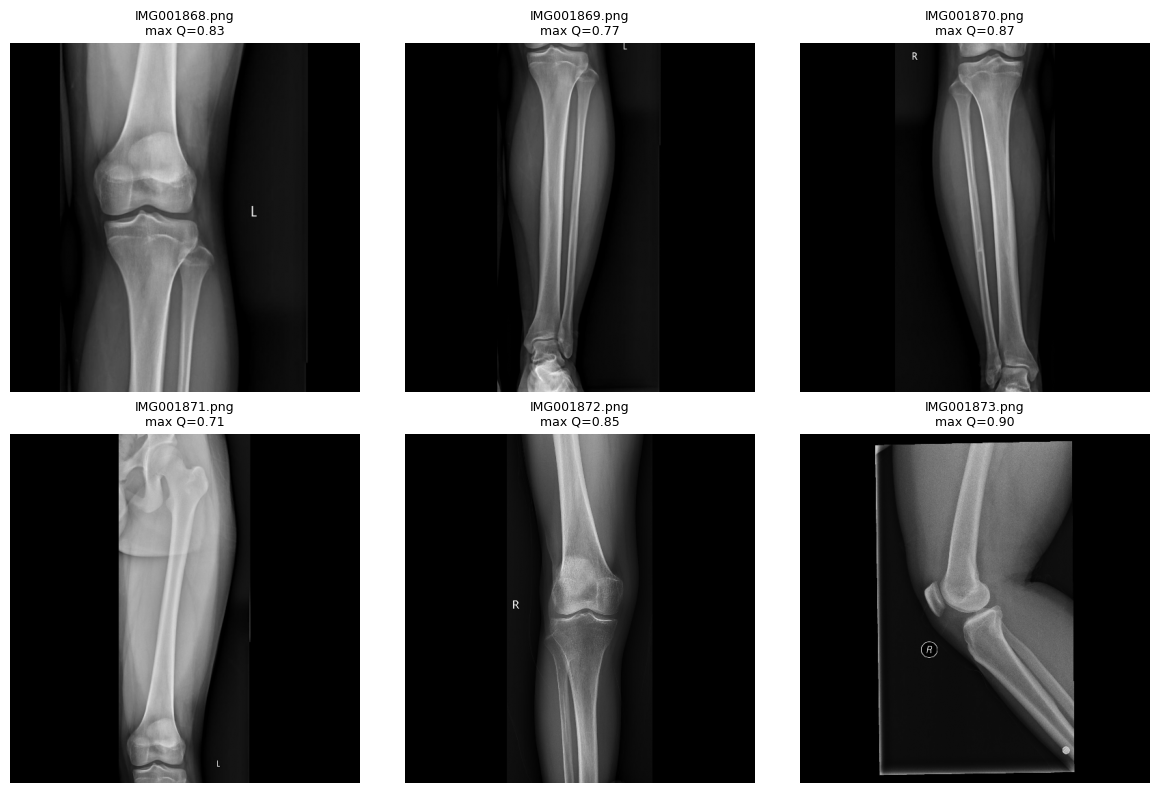

In [5]:
# -- Part N qualitative: a few normal images with their highest-Q box ---
from matplotlib.patches import Rectangle

picks = sorted(set(df['image']))[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img_name in zip(axes.ravel(), picks):
    canvas = load_normal_image(os.path.join(NORMAL_DIR, img_name)) if os.path.exists(os.path.join(NORMAL_DIR, img_name)) \
             else load_normal_image(next(p for p in paths if os.path.basename(p) == img_name))
    sub = df[df.image == img_name].sort_values('q', ascending=False)
    ax.imshow(canvas, cmap='gray')
    ax.set_title(f'{img_name}\nmax Q={sub.q.iloc[0]:.2f}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/boxquality_normal_{DS_NAME.lower()}_examples.png', dpi=150)
plt.show()